# Dataset sanity check

**Purpose**: Quickly verify dataset loading, shapes, masks/targets, and visual inspection for both DeepCrack and COCO-style datasets.

## Prerequisites
- Repository installed/available on PYTHONPATH (or run from `notebooks/`).
- Datasets available locally (update `data_dir`).
- Matplotlib + PyTorch installed.

## How to run
- Run cells top-to-bottom.
- Change `dataset_type` and `data_dir` inside the `DummyConfig` blocks to point to your dataset.

## Notes
- Paths in this notebook are repository- and machine-specific; update them before running.
- If you're running from the `notebooks/` folder, the `PROJECT_ROOT` logic should work as-is.


# Dataset Sanity Check

This notebook validates:
- dataset loading
- tensor shapes & dtypes
- visual alignment of images and labels

Run this notebook before training or active learning.

In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_modules.factory import load_dataset

Data modules package initialized.


## DeepCrack Dataset

This section loads the **DeepCrack** segmentation dataset and checks:
- Dataset lengths
- Example image/mask rendering
- Tensor shapes/dtypes and mask value range


In [3]:
class DummyConfig:
    dataset_type = "deepcrack"  
    data_dir = "/home3/vzcl68/Datasets/DeepCrack/"
    img_size = 256
    num_classes = 2

In [4]:
config = DummyConfig()

train_ds = load_dataset(config, split="train")
val_ds   = load_dataset(config, split="test")

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))


[DeepCrack] 300 samples loaded for split='train'
[DeepCrack] 237 samples loaded for split='test'
Train size: 300
Val size: 237


In [5]:
def show_sample(dataset, idx=0):
    image, mask = dataset[idx]

    if mask.ndim == 3:  # one-hot
        mask_vis = mask.argmax(0)
    else:
        mask_vis = mask

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(image.permute(1, 2, 0))
    axs[0].set_title("Image")
    axs[0].axis("off")

    axs[1].imshow(mask_vis, cmap="gray")
    axs[1].set_title("Mask")
    axs[1].axis("off")

    plt.show()


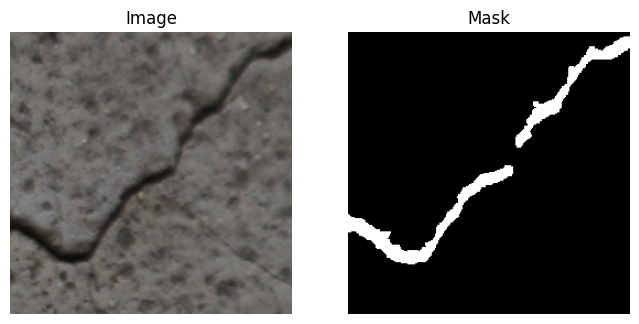

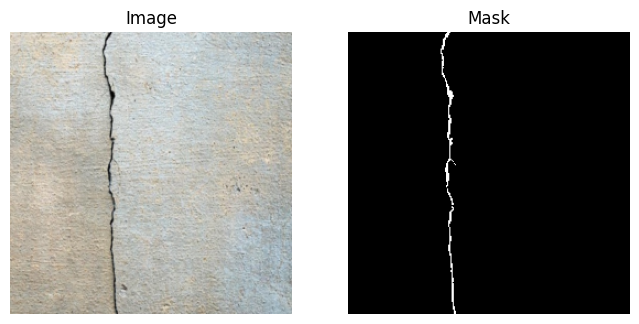

In [6]:
show_sample(train_ds, idx=0)
show_sample(train_ds, idx=10)

In [7]:
img, mask = train_ds[0]

print("Image shape:", img.shape, img.dtype)
print("Mask shape:", mask.shape, mask.dtype)
print("Unique mask values:", torch.unique(mask))

Image shape: torch.Size([3, 256, 256]) torch.float32
Mask shape: torch.Size([2, 256, 256]) torch.float32
Unique mask values: tensor([0., 1.])


## Coco based Dataset
For both Segmentation and Detection Tasks

This section loads **COCO-style** datasets (detection and segmentation) and visualizes:
- Bounding boxes (detection)
- Segmentation masks (segmentation)

If your COCO categories differ, ensure `num_classes` matches (including background if required by your model).

In [8]:
def show_coco_detection(dataset, idx=0):
    image, target = dataset[idx]
    img = image.permute(1, 2, 0)

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img)

    for box in target["boxes"]:
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="r", facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title("COCO Detection")
    ax.axis("off")
    plt.show()

In [9]:
def show_coco_seg(dataset, idx=0):
    image, mask = dataset[idx]

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(image.permute(1, 2, 0))
    axs[0].axis("off")

    axs[1].imshow(mask, cmap="gray")
    axs[1].axis("off")

    plt.show()

In [10]:
class DummyConfig:
    dataset_type = "coco_detection"   
    data_dir = '/home3/vzcl68/Datasets/Italian_Tunnel/'
    img_size = 256
    num_classes = 5

In [11]:
config = DummyConfig()

train_ds = load_dataset(config, split="train")
val_ds   = load_dataset(config, split="test")

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
Train size: 1620
Val size: 180


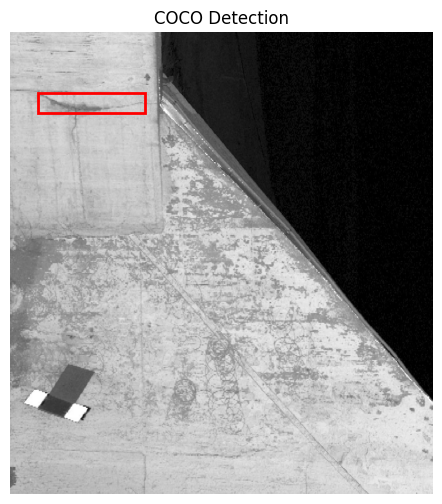

In [12]:
show_coco_detection(train_ds)

In [13]:
class DummyConfig:
    dataset_type = "coco_segmentation"   # change to test others
    data_dir = '/home3/vzcl68/Datasets/Italian_Tunnel/'
    img_size = 256
    num_classes = 5

In [14]:
config = DummyConfig()

train_ds = load_dataset(config, split="train")
val_ds   = load_dataset(config, split="test")

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Train size: 1620
Val size: 180


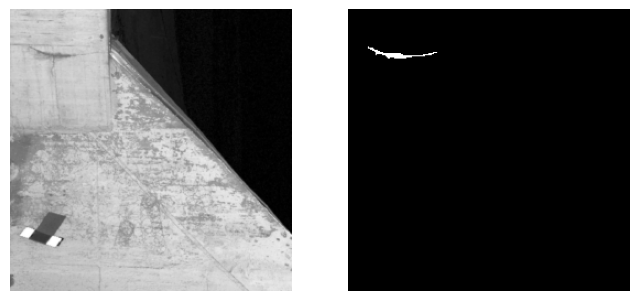

In [15]:
show_coco_seg(train_ds)